# ARC-AGI-3 - Duck tn36 Level-1 Helper

**Experiment:** EXP-DUCK-013

This isolated validation uses a board-signature gate to identify the observed six toggles and submit object. It clicks each toggle once, submits, and stops. The LLM is not called, so success must come from the inferred mechanic itself.


# Tufa Labs ARC3 submission

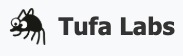

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
# 2026-07-04 preflight: verify Kaggle input mounts before running the public Duck harness.
from pathlib import Path
import os, json, sys

print("Python:", sys.version)
print("KAGGLE_IS_COMPETITION_RERUN:", os.environ.get("KAGGLE_IS_COMPETITION_RERUN"))
print("Kaggle input exists:", Path("/kaggle/input").exists())
print("Kaggle working exists:", Path("/kaggle/working").exists())

expected_hint_paths = [
    "/kaggle/input/competitions/arc-prize-2026-arc-agi-3",
    "/kaggle/input/taaf-kaggle-source-share",
    "/kaggle/input/arc3-vllm-h100-wheelhouse-v3",
    "/kaggle/input/vrfai-qwen3-6-27b-fp8-hf-snapshot",
]

for p in expected_hint_paths:
    path = Path(p)
    print(f"{p}: {'FOUND' if path.exists() else 'not found / maybe mounted elsewhere'}")

print("\nTop-level /kaggle/input entries:")
if Path("/kaggle/input").exists():
    for child in sorted(Path("/kaggle/input").iterdir()):
        print(" -", child)
else:
    print("Not running on Kaggle, or /kaggle/input is unavailable.")


In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
    print(f"taaf.kaggle: setup command: {command}", flush=True)
    subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
    # Re-read in case the command persisted new env keys.
    env = _command_env()
    os.environ.update(env)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 4B. Patch controlled stall policy into the mounted source

Copy the `ARC3-Inference` source bundle into `/kaggle/working`, patch the solver adapter, and prepend that patched source before unpickling the benchmark. This keeps the original Kaggle input read-only and makes the change explicit in notebook output.


In [ ]:
# Controlled stall-policy source patch.
# This edits only the copied source in /kaggle/working, not the read-only Kaggle input.
import shutil

PATCH_ROOT = WORKING_DIR / "duck_controlled_stall_source"
PATCH_REPO = PATCH_ROOT / "ARC3-Inference"
ORIGINAL_REPO = BUNDLE_DIR / "src" / "ARC3-Inference"

if PATCH_REPO.exists():
    shutil.rmtree(PATCH_REPO)
PATCH_ROOT.mkdir(parents=True, exist_ok=True)
shutil.copytree(ORIGINAL_REPO, PATCH_REPO)

solver_py = PATCH_REPO / "inference" / "framework" / "solver.py"
text = solver_py.read_text(encoding="utf-8")

marker = "    def should_stop(self) -> bool:\n"
insert = '''    def _controlled_stall_policy(self) -> dict[str, Any]:
        policy = getattr(self.solver, "controlled_stall_policy", None)
        if not isinstance(policy, dict) or not policy.get("enabled"):
            return {}
        target_ids = policy.get("target_game_ids") or []
        if target_ids:
            run = self.game.game_run
            game_id = run.game_id if run is not None else str(self.game_index)
            if game_id not in set(str(item) for item in target_ids):
                return {}
        return policy

    def _controlled_stall_reason(self) -> str | None:
        policy = self._controlled_stall_policy()
        if not policy:
            return None
        min_actions = int(policy.get("min_actions", 0) or 0)
        if self.action_count < min_actions:
            return None
        no_progress_limit = int(policy.get("max_no_level_progress_actions", 0) or 0)
        if no_progress_limit > 0 and int(getattr(self, "_stall_no_level_progress_actions", 0)) >= no_progress_limit:
            return f"no_level_progress_actions>={no_progress_limit}"
        zero_limit = int(policy.get("max_consecutive_zero_token_actions", 0) or 0)
        if zero_limit > 0 and int(getattr(self, "_stall_consecutive_zero_token_actions", 0)) >= zero_limit:
            return f"consecutive_zero_token_actions>={zero_limit}"
        return None

    def _update_controlled_stall_counters(self, payload: dict[str, Any], generated_tokens: int) -> None:
        made_level_progress = bool(payload.get("level_completed")) or bool(payload.get("run_complete"))
        try:
            made_level_progress = made_level_progress or float(payload.get("reward", 0.0) or 0.0) > 0.0
        except (TypeError, ValueError):
            pass
        if made_level_progress:
            self._stall_no_level_progress_actions = 0
        else:
            self._stall_no_level_progress_actions = int(getattr(self, "_stall_no_level_progress_actions", 0)) + 1
        if int(generated_tokens or 0) == 0:
            self._stall_consecutive_zero_token_actions = int(getattr(self, "_stall_consecutive_zero_token_actions", 0)) + 1
        else:
            self._stall_consecutive_zero_token_actions = 0

'''
if insert.strip() not in text:
    text = text.replace(marker, insert + marker)

old_should_stop = '''        if (
            self.solver.max_actions_per_game is not None
            and self.action_count >= self.solver.max_actions_per_game
        ):
            return True
        return False
'''
new_should_stop = '''        if (
            self.solver.max_actions_per_game is not None
            and self.action_count >= self.solver.max_actions_per_game
        ):
            return True
        controlled_stall_reason = self._controlled_stall_reason()
        if controlled_stall_reason is not None:
            if run.solver_note is None:
                run.solver_note = f"controlled_stall={controlled_stall_reason}; tokens={_analyzer_reported_tokens(self.analyzer)}"
            return True
        return False
'''
if old_should_stop not in text:
    raise RuntimeError("Could not patch should_stop(); source shape changed.")
text = text.replace(old_should_stop, new_should_stop)

old_execute = '''        self._append_action_viewer_event(payload, current_frame)
        if flush_viewer_payload:
            self.write_viewer_payload()
        return payload
'''
new_execute = '''        self._update_controlled_stall_counters(payload, generated_tokens)
        self._append_action_viewer_event(payload, current_frame)
        if flush_viewer_payload:
            self.write_viewer_payload()
        return payload
'''
if old_execute not in text:
    raise RuntimeError("Could not patch _execute_action(); source shape changed.")
text = text.replace(old_execute, new_execute)
solver_py.write_text(text, encoding="utf-8")

# Prepend patched source before loading benchmark_initial.pkl, whose solver class lives in inference.framework.solver.
patched_source_root = str(PATCH_REPO)
if patched_source_root not in sys.path:
    sys.path.insert(0, patched_source_root)
for module_name in ["inference.framework.solver"]:
    sys.modules.pop(module_name, None)

print("Patched solver source:", solver_py)
print("Prepended patched source root:", patched_source_root)


# Signature-gated tn36 level-1 helper patch.
reki_helper_py = PATCH_REPO / "inference" / "framework" / "reki_fallback.py"
tn36_helper_py = PATCH_REPO / "inference" / "framework" / "tn36_level1_helper.py"
reki_helper_py.write_text('"""Fallback-only Reki-style salient click selection for Duck experiments.\n\nThe ledger may learn from every observed click, but it never rejects an LLM\naction. Its dead signatures and exact-state failures are consulted only when a\nseparate stall policy explicitly asks for a fallback click.\n"""\n\nfrom __future__ import annotations\n\nfrom collections import Counter, defaultdict, deque\nfrom typing import Any, Iterable\n\n\nGrid = tuple[tuple[int, ...], ...]\nSignature = tuple[int, int, int, int]\n\n\ndef normalize_grid(board: Iterable[Iterable[Any]]) -> Grid:\n    return tuple(tuple(int(cell) for cell in row) for row in board)\n\n\ndef dominant_color(grid: Grid) -> int:\n    counts = Counter(cell for row in grid for cell in row)\n    return counts.most_common(1)[0][0] if counts else 0\n\n\ndef comparison_grid(grid: Grid, border: int = 3) -> Grid:\n    if border <= 0 or len(grid) <= border * 2:\n        return grid\n    trimmed = []\n    for row in grid[border:-border]:\n        trimmed.append(row[border:-border] if len(row) > border * 2 else row)\n    return tuple(trimmed)\n\n\ndef changed_cells(before: Grid, after: Grid, border: int = 3) -> int:\n    left = comparison_grid(before, border)\n    right = comparison_grid(after, border)\n    height = max(len(left), len(right))\n    width = max(\n        max((len(row) for row in left), default=0),\n        max((len(row) for row in right), default=0),\n    )\n    changed = 0\n    for row in range(height):\n        left_row = left[row] if row < len(left) else ()\n        right_row = right[row] if row < len(right) else ()\n        for col in range(width):\n            left_value = left_row[col] if col < len(left_row) else 0\n            right_value = right_row[col] if col < len(right_row) else 0\n            changed += left_value != right_value\n    return changed\n\n\ndef components(grid: Grid) -> list[dict[str, Any]]:\n    """Return non-background 4-connected components with Reki signatures."""\n    if not grid:\n        return []\n    background = dominant_color(grid)\n    height = len(grid)\n    seen: set[tuple[int, int]] = set()\n    result: list[dict[str, Any]] = []\n\n    for start_row, values in enumerate(grid):\n        for start_col, color in enumerate(values):\n            if color == background or (start_row, start_col) in seen:\n                continue\n            queue = deque([(start_row, start_col)])\n            seen.add((start_row, start_col))\n            pixels: list[tuple[int, int]] = []\n            while queue:\n                row, col = queue.popleft()\n                pixels.append((row, col))\n                for next_row, next_col in (\n                    (row - 1, col),\n                    (row + 1, col),\n                    (row, col - 1),\n                    (row, col + 1),\n                ):\n                    if (next_row, next_col) in seen:\n                        continue\n                    if next_row < 0 or next_row >= height:\n                        continue\n                    if next_col < 0 or next_col >= len(grid[next_row]):\n                        continue\n                    if grid[next_row][next_col] != color:\n                        continue\n                    seen.add((next_row, next_col))\n                    queue.append((next_row, next_col))\n\n            rows = [position[0] for position in pixels]\n            cols = [position[1] for position in pixels]\n            center_row = sum(rows) / len(rows)\n            center_col = sum(cols) / len(cols)\n            click_row, click_col = min(\n                pixels,\n                key=lambda position: abs(position[0] - center_row)\n                + abs(position[1] - center_col),\n            )\n            bbox_area = (max(rows) - min(rows) + 1) * (max(cols) - min(cols) + 1)\n            result.append(\n                {\n                    "color": color,\n                    "size": len(pixels),\n                    "is_rect": int(len(pixels) == bbox_area),\n                    "row": click_row,\n                    "col": click_col,\n                    "pixels": frozenset(pixels),\n                }\n            )\n\n    twin_counts = Counter(\n        (item["color"], item["size"], item["is_rect"]) for item in result\n    )\n    total_cells = sum(len(row) for row in grid)\n    color_counts = Counter(cell for row in grid for cell in row)\n    for item in result:\n        base = (item["color"], item["size"], item["is_rect"])\n        item["signature"] = (*base, twin_counts[base] - 1)\n        rarity = 1.0 - color_counts[item["color"]] / max(total_cells, 1)\n        size = item["size"]\n        size_score = (\n            1.0\n            if size <= 4\n            else 0.8\n            if size <= 16\n            else 0.5\n            if size <= 64\n            else 0.25\n            if size <= 256\n            else 0.0\n        )\n        item["saliency"] = 0.5 * rarity + 0.5 * size_score\n    return result\n\n\ndef signature_at(grid: Grid, row: int, col: int) -> Signature | None:\n    if row < 0 or row >= len(grid) or col < 0 or col >= len(grid[row]):\n        return None\n    if grid[row][col] == dominant_color(grid):\n        return None\n    for item in components(grid):\n        if (row, col) in item["pixels"]:\n            return item["signature"]\n    return None\n\n\nclass FallbackClickLedger:\n    def __init__(self, dead_threshold: int = 2, border_ignore: int = 3) -> None:\n        self.dead_threshold = max(1, int(dead_threshold))\n        self.border_ignore = max(0, int(border_ignore))\n        self.level: int | None = None\n        self.dead_signatures: set[Signature] = set()\n        self.effective_signatures: set[Signature] = set()\n        self.dead_counts: defaultdict[Signature, int] = defaultdict(int)\n        self.failed_state_clicks: defaultdict[Grid, set[tuple[int, int]]] = defaultdict(set)\n        self.fallback_attempts = 0\n        self.total_fallback_attempts = 0\n        self.fallback_exhausted = False\n        self.observed_clicks = 0\n        self.fallback_effective = 0\n        self.fallback_no_effect = 0\n\n    def ensure_level(self, level: int) -> None:\n        level = int(level)\n        if self.level == level:\n            return\n        self.level = level\n        self.dead_signatures.clear()\n        self.effective_signatures.clear()\n        self.dead_counts.clear()\n        self.failed_state_clicks.clear()\n        self.fallback_attempts = 0\n        self.fallback_exhausted = False\n\n    def choose(self, board: Iterable[Iterable[Any]], level: int) -> dict[str, Any] | None:\n        self.ensure_level(level)\n        grid = normalize_grid(board)\n        failed = self.failed_state_clicks.get(grid, set())\n        ranked = sorted(\n            components(grid),\n            key=lambda item: (item["saliency"], -item["size"]),\n            reverse=True,\n        )\n        for item in ranked:\n            coordinate = (item["row"], item["col"])\n            if item["signature"] in self.dead_signatures or coordinate in failed:\n                continue\n            self.fallback_attempts += 1\n            self.total_fallback_attempts += 1\n            return {\n                "row": item["row"],\n                "col": item["col"],\n                "signature": item["signature"],\n                "saliency": item["saliency"],\n            }\n        self.fallback_exhausted = True\n        return None\n\n    def observe(\n        self,\n        before: Iterable[Iterable[Any]],\n        after: Iterable[Iterable[Any]],\n        level_before: int,\n        level_after: int,\n        row: int,\n        col: int,\n        *,\n        fallback: bool = False,\n    ) -> dict[str, Any]:\n        self.ensure_level(level_before)\n        before_grid = normalize_grid(before)\n        after_grid = normalize_grid(after)\n        signature = signature_at(before_grid, int(row), int(col))\n        changed = changed_cells(before_grid, after_grid, self.border_ignore)\n        progressed = int(level_after) != int(level_before)\n        effective = bool(changed or progressed)\n        self.observed_clicks += 1\n        if fallback:\n            if effective:\n                self.fallback_effective += 1\n            else:\n                self.fallback_no_effect += 1\n\n        if signature is not None:\n            if effective:\n                self.effective_signatures.add(signature)\n                self.dead_counts.pop(signature, None)\n                self.dead_signatures.discard(signature)\n            elif signature not in self.effective_signatures:\n                self.failed_state_clicks[before_grid].add((int(row), int(col)))\n                self.dead_counts[signature] += 1\n                if self.dead_counts[signature] >= self.dead_threshold:\n                    self.dead_signatures.add(signature)\n\n        if progressed:\n            self.ensure_level(level_after)\n        return {\n            "signature": signature,\n            "changed_cells": changed,\n            "level_progress": progressed,\n            "effective": effective,\n            "dead_after": signature in self.dead_signatures if signature else False,\n        }\n\n    def summary(self) -> dict[str, Any]:\n        return {\n            "level": self.level,\n            "fallback_attempts": self.fallback_attempts,\n            "total_fallback_attempts": self.total_fallback_attempts,\n            "fallback_exhausted": self.fallback_exhausted,\n            "observed_clicks": self.observed_clicks,\n            "fallback_effective": self.fallback_effective,\n            "fallback_no_effect": self.fallback_no_effect,\n            "dead_signatures": len(self.dead_signatures),\n            "effective_signatures": len(self.effective_signatures),\n        }\n', encoding="utf-8")
tn36_helper_py.write_text('"""Signature-gated deterministic plan for tn36 level 1."""\n\nfrom __future__ import annotations\n\nfrom typing import Any, Iterable\n\ntry:\n    from .reki_fallback import components, normalize_grid\nexcept ImportError:\n    from reki_fallback import components, normalize_grid\n\n\ndef plan_tn36_level1(board: Iterable[Iterable[Any]]) -> list[dict[str, int]] | None:\n    found = components(normalize_grid(board))\n    toggles = sorted(\n        (\n            item\n            for item in found\n            if item["color"] == 1 and item["size"] == 3 and item["is_rect"] == 1\n        ),\n        key=lambda item: (item["row"], item["col"]),\n    )\n    submit = [\n        item\n        for item in found\n        if item["color"] == 9 and item["size"] == 69 and item["is_rect"] == 0\n    ]\n    clue_shapes = sorted(\n        (item["size"] for item in found if item["color"] == 11),\n    )\n\n    # These guards describe the observed level family, not just coordinates.\n    if len(toggles) != 6 or len(submit) != 1 or clue_shapes != [14, 16]:\n        return None\n    if [item["row"] for item in toggles] != [42, 42, 42, 45, 45, 45]:\n        return None\n    if [item["col"] for item in toggles] != [26, 36, 41, 26, 36, 41]:\n        return None\n\n    actions = [\n        {"row": int(item["row"]), "col": int(item["col"])} for item in toggles\n    ]\n    actions.append({"row": int(submit[0]["row"]), "col": int(submit[0]["col"])})\n    return actions\n', encoding="utf-8")

text = solver_py.read_text(encoding="utf-8")
import_anchor = "from inference.framework.kaggle import (\n"
helper_import = "from inference.framework.tn36_level1_helper import plan_tn36_level1\n"
if helper_import not in text:
    if import_anchor not in text:
        raise RuntimeError("Could not add tn36 helper import; source shape changed.")
    text = text.replace(import_anchor, helper_import + import_anchor, 1)

methods_anchor = "    def _controlled_stall_policy(self) -> dict[str, Any]:\n"
helper_methods = r'''    def _tn36_level1_helper_policy(self) -> dict[str, Any]:
        policy = getattr(self.solver, "tn36_level1_helper_policy", None)
        if not isinstance(policy, dict) or not policy.get("enabled"):
            return {}
        run = self.game.game_run
        game_id = run.game_id if run is not None else str(self.game_index)
        target_ids = {str(item) for item in policy.get("target_game_ids") or []}
        if target_ids and game_id not in target_ids:
            return {}
        return policy

    def _tn36_level1_note(self, message: str) -> None:
        run = self.game.game_run
        if run is not None:
            run.solver_note = f"{message}; {run.solver_note}" if run.solver_note else message

    def _try_tn36_level1_helper(self) -> bool:
        policy = self._tn36_level1_helper_policy()
        if not policy or _is_engine_game_over(self.game) or _level_number(self.game) != 1:
            return False
        if bool(getattr(self, "_tn36_level1_helper_tried", False)):
            return False
        self._tn36_level1_helper_tried = True

        plan = plan_tn36_level1(_grid_from_state(self.game.current_state))
        if plan is None:
            self._tn36_level1_note("tn36_level1_helper=signature_mismatch; helper_actions=0")
            self._tn36_level1_helper_stop = True
            self.write_viewer_payload()
            return True

        executed = 0
        for batch_index, click in enumerate(plan, start=1):
            action = arcengine.ActionInput(
                id=arcengine.GameAction.ACTION6,
                data={"x": int(click["col"]), "y": int(click["row"])} ,
            )
            payload = self._execute_action(
                action,
                batch_index=batch_index,
                batch_size=len(plan),
                generated_tokens=0,
                flush_viewer_payload=False,
            )
            executed += 1
            if payload.get("level_completed") or payload.get("run_complete") or payload.get("game_over"):
                outcome = "success" if payload.get("level_completed") else "terminal_without_progress"
                self._tn36_level1_note(
                    f"tn36_level1_helper={outcome}; helper_actions={executed}"
                )
                self._tn36_level1_helper_stop = True
                self.write_viewer_payload()
                return True

        self._tn36_level1_note(f"tn36_level1_helper=no_progress; helper_actions={executed}")
        self._tn36_level1_helper_stop = True
        self.write_viewer_payload()
        return True

'''
if helper_methods.strip() not in text:
    if methods_anchor not in text:
        raise RuntimeError("Could not add tn36 helper methods; stall patch missing.")
    text = text.replace(methods_anchor, helper_methods + methods_anchor, 1)

should_stop_anchor = "    def should_stop(self) -> bool:\n        run = self.game.game_run\n"
should_stop_replacement = "    def should_stop(self) -> bool:\n        if bool(getattr(self, '_tn36_level1_helper_stop', False)):\n            return True\n        run = self.game.game_run\n"
if should_stop_anchor not in text:
    raise RuntimeError("Could not add tn36 helper stop flag.")
text = text.replace(should_stop_anchor, should_stop_replacement, 1)

play_anchor = "            while not self.should_stop():\n                if (\n"
play_replacement = "            while not self.should_stop():\n                if self._try_tn36_level1_helper():\n                    continue\n                if (\n"
if play_anchor not in text:
    raise RuntimeError("Could not add tn36 helper to play loop.")
text = text.replace(play_anchor, play_replacement, 1)

solver_py.write_text(text, encoding="utf-8")
for module_name in [
    "inference.framework.reki_fallback",
    "inference.framework.tn36_level1_helper",
    "inference.framework.solver",
]:
    sys.modules.pop(module_name, None)
print("Added signature-gated tn36 level-1 helper:", tn36_helper_py)


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# EXP-DUCK-013 isolated tn36 level-1 helper validation.
DUCK_REPRO_LABEL = "duck-tn36-level1-helper-20260721"
LIMIT_TO_GAME_IDS = ["tn36-ef4dde99"]
MAX_GAMES_FOR_DEBUG = None

TN36_LEVEL1_HELPER_POLICY = {
    "enabled": True,
    "target_game_ids": LIMIT_TO_GAME_IDS,
    "stop_after_attempt": True,
}

bm.label = f"{getattr(bm, 'label', 'duck')}-{DUCK_REPRO_LABEL}"
bm.solver.controlled_stall_policy = {"enabled": False}
bm.solver.tn36_level1_helper_policy = dict(TN36_LEVEL1_HELPER_POLICY)
bm.solver.max_actions_per_game = 8
bm.solver.max_runtime_s_per_game = min(
    float(getattr(bm.solver, "max_runtime_s_per_game", 7920.0) or 7920.0),
    1200.0,
)
bm.solver.concurrency = 1
print("Benchmark label:", bm.label)
print("tn36 level-1 helper policy:", json.dumps(TN36_LEVEL1_HELPER_POLICY, sort_keys=True))

def _game_id(g):
    for attr in ("game_id", "env_name", "name"):
        value = getattr(g, attr, None)
        if value:
            return str(value)
    return str(g)

def _apply_target_game_filter(games):
    filtered = list(games)
    original_n_games = len(filtered)
    wanted = set(LIMIT_TO_GAME_IDS)
    filtered = [g for g in filtered if _game_id(g) in wanted]
    print(f"Filtered games after game-list construction: {original_n_games} -> {len(filtered)}")
    print("Selected games:", [_game_id(g) for g in filtered])
    return filtered


In [ ]:
# 2026-07-04 reproducibility manifest.
# This does not change the Duck harness. It only writes a small manifest to /kaggle/working.
from pathlib import Path
import json, os, time, platform

manifest = {
    "session": "2026-07-04",
    "notebook_role": "duck_public_repro_workbench",
    "run_as_competition_rerun": os.environ.get("KAGGLE_IS_COMPETITION_RERUN", ""),
    "platform": platform.platform(),
    "python": platform.python_version(),
    "time_epoch": time.time(),
    "notes": [
        "Run unchanged first.",
        "Use outputs as baseline artifact before modifying the customization hook.",
        "Do not claim improvement until validated by diagnostics or Kaggle score."
    ],
}
working = Path("/kaggle/working")
if working.exists():
    out_path = working / "arc3_duck_repro_manifest_20260704.json"
    out_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + "\n")
    print("Wrote:", out_path)
else:
    print(json.dumps(manifest, indent=2, sort_keys=True))


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Print the run preamble and persist the launcher's git status for diagnostics.
print((BUNDLE_DIR / "preamble.txt").read_text())
(WORKING_DIR / "git_status.txt").write_text((BUNDLE_DIR / "git_status.txt").read_text())

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels").parent / "environment_files")
    bm.games = _offline_games(competition_env_files)

bm.games = _apply_target_game_filter(bm.games)
if not bm.games:
    raise RuntimeError("Target game filter selected zero games.")

bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
soft_end = None
if not TRUE_SUBMISSION:
    budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
    if budget > 0:
        soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(seconds=budget - min(600.0, budget / 2))

# Play the benchmark; teardown commands run even if the run raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=TRUE_SUBMISSION)
    if not TRUE_SUBMISSION:
        # An offline run isn't scored, but Kaggle still expects a submission.parquet output.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)
finally:
    for command in json.loads((BUNDLE_DIR / "teardown_commands.json").read_text()):
        print(f"taaf.kaggle: teardown command: {command}", flush=True)
        subprocess.run(command, shell=True, check=False, cwd=WORKING_DIR, env=_command_env())

## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")

## 9. After baseline reproduction

Do not edit the solver yet. First create a per-game comparison plan:

```text
game_id | our_baseline_score | duck_score | duck_behavior | reusable_component
```

Recommended first build-on-top variants:

1. **Duck-Repro-A:** exact public notebook, no edits.
2. **Duck-Repro-B:** targeted diagnostics on games where our agent fails but Duck makes progress.
3. **Duck-Lite-001:** port segmentation and trace diagnostics into our existing offline workbench.
4. **Duck-Lite-002:** add a compact world-model field while retaining deterministic fallback policy.

Validation rule:

```text
No improvement claim unless backed by diagnostics, local/offline public-game logs, or Kaggle submission score.
```
